## STEP 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
sns.set(style="whitegrid")
print("Libraries Imported Successfully")

Libraries Imported Successfully


## STEP 2 — Load Cleaned Dataset

In [2]:
df = pd.read_csv(
    "D:/Thiranex/cleaned_data/cleaned_netflix_dataset.csv"
)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


## STEP 3 — Select Required Columns

In [3]:
df = df[[
    'type',
    'release_year',
    'country',
    'rating'
]]
df.head()

,type,release_year,country,rating
0,Movie,2020,United States,PG-13
1,TV Show,2021,South Africa,TV-MA
2,TV Show,2021,Unknown,TV-MA
3,TV Show,2021,Unknown,TV-MA
4,TV Show,2021,India,TV-MA


## STEP 4 — Check Missing Values

In [4]:
df.isnull().sum()

type            0
release_year    0
country         0
rating          0
dtype: int64

## STEP 5 — Encode Categorical Data

In [5]:
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
df.head()

,type,release_year,country,rating
0,0,72,603,7
1,1,73,426,11
2,1,73,736,11
3,1,73,736,11
4,1,73,251,11


## STEP 6 — Define Features and Target

In [6]:
X = df.drop('type', axis=1)
y = df['type']
print(X.head())

   release_year  country  rating
0            72      603       7
1            73      426      11
2            73      736      11
3            73      736      11
4            73      251      11


## STEP 7 — Split Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (7045, 3)
Testing Data: (1762, 3)


## STEP 8 — Logistic Regression

In [8]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.6929625425652668


## STEP 9 — Decision Tree

In [9]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy:
0.7480136208853575


## STEP 10 — Random Forest

In [10]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:
0.7491486946651532


## STEP 11 — Confusion Matrix

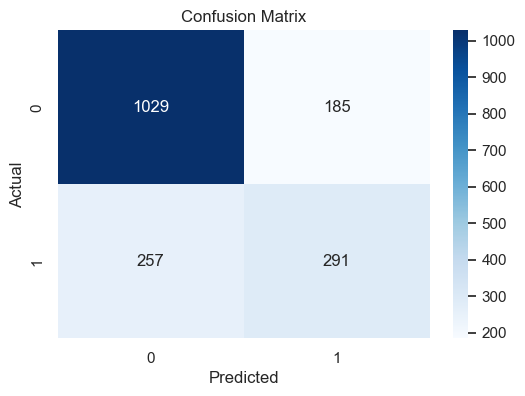

In [11]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## STEP 12 — Classification Report

In [12]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82      1214
           1       0.61      0.53      0.57       548

    accuracy                           0.75      1762
   macro avg       0.71      0.69      0.70      1762
weighted avg       0.74      0.75      0.74      1762



## STEP 13 — ROC Curve

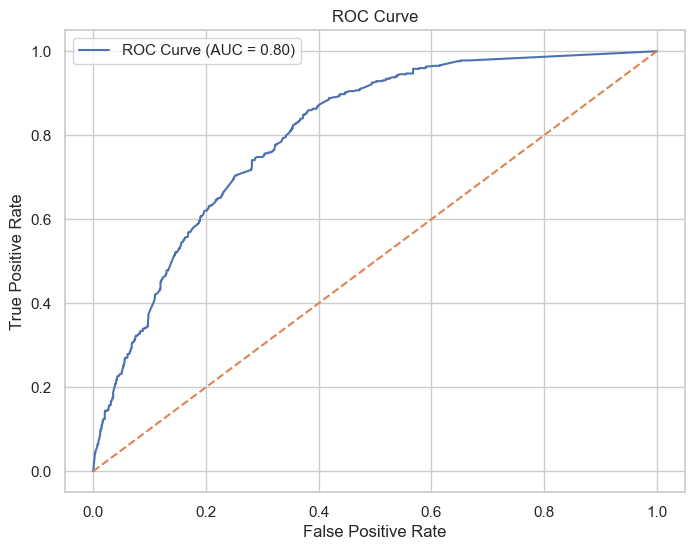

In [13]:
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr,
    label='ROC Curve (AUC = %0.2f)' % roc_auc
)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## STEP 14 — Feature Importance

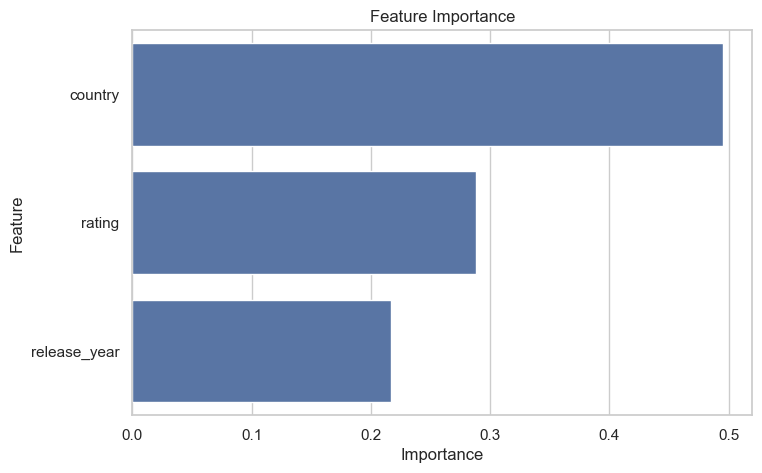

In [14]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()

## STEP 15 — Final Insights

# Final Insights

1. Random Forest achieved the best prediction accuracy.

2. Release year and rating strongly influence whether content is a Movie or TV Show.

3. Machine Learning models successfully classified Netflix content types.

4. ROC Curve indicates good model performance.

## STEP 16 — Save Prediction Results

In [15]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_rf
})

results.to_csv(
    "cleaned_data/prediction_results.csv",
    index=False
)

print("Prediction Results Saved Successfully")

OSError: Cannot save file into a non-existent directory: 'cleaned_data'